# Notebook: Clasificación HAM10000 con ResNet50

## 1: Instalación de dependencias

In [ ]:
## Instalación definitiva y limpieza de conflictos
#%pip install -q \
#    "tensorflow[and-cuda]==2.16.1" \
#    tf-keras==2.16.0 \
#    keras-cv==0.9.0 \
#    keras-cv-attention-models \
#    pandas matplotlib scikit-learn ipywidgets seaborn \
#    lime shap opencv-python \
#    python-dotenv kaggle \
#    optuna optuna-dashboard optuna-integration \
#    pydot
#
#
## Borramos Keras 3 justo después por si TensorFlow lo ha vuelto a instalar
## %pip uninstall -y keras keras-core
#
## Hay que instalar manualmente graphviz
## sudo apt install graphviz
#
## Después tendrás que reiniciar el kernel

In [ ]:
# Cargamos las variables de entorno del archivo .env
import os
from dotenv import load_dotenv

# Carga las variables del archivo .env al entorno del sistema
load_dotenv()

## 2: Configuración de la GPU y librerías

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Standard library
# ─────────────────────────────────────────────────────────────────────────────
import contextlib
import datetime
import gc
import os
import site
import traceback

# ─────────────────────────────────────────────────────────────────────────────
# Third-party libraries
# ─────────────────────────────────────────────────────────────────────────────
import keras
from keras import layers, models, mixed_precision
from keras.applications import ResNet50
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import shap
import tensorflow as tf

from lime import lime_image
from optuna_integration import TFKerasPruningCallback
from skimage.segmentation import mark_boundaries, quickshift, slic, felzenszwalb, watershed
from skimage.filters import sobel
from skimage.color import rgb2gray

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight





# 1. Forzamos modo Legacy para que TensorFlow use Keras 2 en lugar de Keras 3 (que es la que hemos instalado)
os.environ["TF_USE_LEGACY_KERAS"] = "1"
# 2. Quitamos el aviso de oneDNN (para que el log sea más limpio)
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

# 3. LE INDICAMOS A TENSORFLOW DÓNDE ESTÁN TUS LIBRERÍAS DE NVIDIA
# Buscamos las que instaló el comando [and-cuda] arriba

for path in site.getsitepackages():
    nvidia_path = os.path.join(path, "nvidia/cudnn/lib")
    if os.path.exists(nvidia_path):
        os.environ["LD_LIBRARY_PATH"] = nvidia_path + ":" + os.environ.get("LD_LIBRARY_PATH", "")

# Añadimos la ruta del driver de Windows en WSL2
os.environ["LD_LIBRARY_PATH"] = "/usr/lib/wsl/lib:" + os.environ.get("LD_LIBRARY_PATH", "")



# Comprobación de la 3080 Ti
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"🔥 ¡CONSEGUIDO! GPU lista: {gpus[0]}")
else:
    print("❌ Seguimos sin ver la GPU. Mira el error de arriba.")

2026-06-02 16:09:51.347041: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-02 16:09:51.495501: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-02 16:09:51.495626: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-02 16:09:51.515164: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-02 16:09:51.577631: I tensorflow/core/platform/cpu_feature_guar

🔥 ¡CONSEGUIDO! GPU lista: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


2026-06-02 16:09:57.248863: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-02 16:09:57.598126: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-02 16:09:57.598373: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-02 16:09:57.598438: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [2]:
import tensorflow as tf

print(tf.__version__)
print(tf.keras)

2.15.0
<module 'tensorflow.keras' from '/home/jesus/repos/TFM/.venv/lib/python3.11/site-packages/keras/api/_v2/keras/__init__.py'>


## 3: Descarga y extracción del Dataset

Nota: debes tener descargado unzip ``sudo apt update && sudo apt install unzip -y``

In [3]:
%%bash
# 1. Definir rutas relativas al proyecto
PROJECT_ROOT=$(pwd)
DATA_DIR="$PROJECT_ROOT/datasets/ham10000"
ZIP_FILE="$DATA_DIR/ham10000-preprocessed.zip"
WITNESS_DIR="$DATA_DIR/organized_ham10000"
META_FILE="$DATA_DIR/HAM10000_metadata.csv"


# 2. Crear la carpeta base si no existe
mkdir -p "$DATA_DIR"

# 3. Lógica para las IMÁGENES (Tu código original)
if [ -d "$WITNESS_DIR" ]; then
    echo "✅ Escenario A: Las carpetas de imágenes ya existen en $WITNESS_DIR. Saltando descarga."
elif [ -f "$ZIP_FILE" ]; then
    echo "📦 Escenario B: ZIP de imágenes encontrado pero no descomprimido. Extrayendo ahora..."
    unzip -q "$ZIP_FILE" -d "$DATA_DIR" && rm "$ZIP_FILE"
    echo "✅ Descompresión terminada y ZIP eliminado."
else
    echo "🌐 Escenario C: No hay imágenes. Iniciando descarga desde Kaggle..."
    curl -L -o "$ZIP_FILE" https://www.kaggle.com/api/v1/datasets/download/rayeedaabir/ham10000-preprocessed
    echo "🚚 Descarga de imágenes finalizada. Descomprimiendo..."
    unzip -q "$ZIP_FILE" -d "$DATA_DIR" && rm "$ZIP_FILE"
fi

# 4. Lógica para los METADATOS (Nueva sección)
if [ -f "$META_FILE" ]; then
    echo "✅ Metadatos encontrados en $META_FILE."
else
    echo "📊 Los metadatos no existen. Descargando HAM10000_metadata.csv desde el dataset original..."
    
    # Descargar solo el archivo CSV del dataset original de kmader
    # Usamos -p para indicar la carpeta de destino
    kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -f HAM10000_metadata.csv -p "$DATA_DIR"
    
    # Kaggle a veces descarga el archivo individual dentro de un .zip
    if [ -f "$DATA_DIR/HAM10000_metadata.csv.zip" ]; then
        unzip -o "$DATA_DIR/HAM10000_metadata.csv.zip" -d "$DATA_DIR"
        rm "$DATA_DIR/HAM10000_metadata.csv.zip"
    fi
    
    echo "✅ Metadatos listos."
fi

echo "🚀 Proceso completo. Imágenes y metadatos preparados en $DATA_DIR"

✅ Escenario A: Las carpetas de imágenes ya existen en /home/jesus/repos/TFM/datasets/ham10000/organized_ham10000. Saltando descarga.
✅ Metadatos encontrados en /home/jesus/repos/TFM/datasets/ham10000/HAM10000_metadata.csv.
🚀 Proceso completo. Imágenes y metadatos preparados en /home/jesus/repos/TFM/datasets/ham10000


## 4: Preparación de datos (Carga desde directorios)

Primero creamos una función que nos permita traducir las etiquetas, para facilitar su lectura

In [4]:
# Parámetros de configuración
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATA_PATH = "datasets/ham10000/organized_ham10000"
META_PATH = "datasets/ham10000/HAM10000_metadata.csv"
AUTOTUNE = tf.data.AUTOTUNE

In [5]:
def get_class_name_es(input_data):
    """
    Traduce las categorías de HAM10000 al español.
    Soporta códigos cortos ('mel') y nombres largos ('Melanoma').
    """
    translations = {
        # Mapeo para nombres largos (los que tienes ahora)
        'actinic keratoses': 'Queratosis actínica',
        'basal cell carcinoma': 'Carcinoma basocelular',
        'benign keratosis': 'Queratosis benigna',
        'dermatofibroma': 'Dermatofibroma',
        'melanocytic nevi': 'Nevus melanocítico',
        'melanoma': 'Melanoma',
        'vascular lesions': 'Lesión vascular',
        
        # Mapeo para códigos cortos (por si acaso)
        'akiec': 'Queratosis actínica',
        'bcc': 'Carcinoma basocelular',
        'bkl': 'Queratosis benigna',
        'df': 'Dermatofibroma',
        'nv': 'Nevus melanocítico',
        'mel': 'Melanoma',
        'vasc': 'Lesión vascular'
    }
    
    def translate(name):
        # Limpiamos el texto: minúsculas y quitar espacios en los extremos
        clean_name = str(name).lower().strip()
        return translations.get(clean_name, name)

    # Si recibimos una lista
    if isinstance(input_data, list):
        return [translate(name) for name in input_data]
    
    # Si recibimos un solo nombre
    return translate(input_data)

Preparamos los metadatos

In [6]:


# 1. Cargar metadatos
df = pd.read_csv(META_PATH)
df.set_index('image_id', inplace=True) # Facilita la búsqueda por ID

# 2. Mapeo de rutas de archivos (SIN PROCESAR METADATOS AÚN)
all_image_paths = []
all_labels = []
all_img_ids = []

class_names = sorted(os.listdir(DATA_PATH))  
folder_to_id = {name: i for i, name in enumerate(class_names)}

for folder in class_names:
    folder_path = os.path.join(DATA_PATH, folder)
    if not os.path.isdir(folder_path): continue
    for img_name in os.listdir(folder_path):
        if img_name.endswith('.jpg'):
            img_id = img_name.replace('.jpg', '')
            if img_id in df.index:
                all_image_paths.append(os.path.join(folder_path, img_name))
                all_labels.append(folder_to_id[folder])
                all_img_ids.append(img_id)

# Creamos el dataframe base combinando rutas con la edad y categorías CRUDA
data_df = pd.DataFrame({
    'path': all_image_paths,
    'label': all_labels,
    'image_id': all_img_ids
})
# Hacemos merge de los metadatos crudos
data_df = data_df.merge(df[['lesion_id', 'age', 'sex', 'localization']], left_on='image_id', right_index=True)

# ==========================================
# 3. DIVISIÓN DEL DATAFRAME (ANTES DEL SCALER)
# ==========================================

# 1. Separar Test (15%) asegurando que las fotos de la misma lesión no se separen
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, test_idx = next(gss_test.split(data_df, data_df['label'], groups=data_df['lesion_id']))

train_val_df = data_df.iloc[train_val_idx].copy()
test_df = data_df.iloc[test_idx].copy()

# 2. Separar Val (15% del total -> ~17.6% del remanente) agrupando de nuevo
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.176, random_state=42)
train_idx, val_idx = next(gss_val.split(train_val_df, train_val_df['label'], groups=train_val_df['lesion_id']))

train_df = train_val_df.iloc[train_idx].copy()
val_df = train_val_df.iloc[val_idx].copy()

print(f"✅ Split Seguro. Pacientes únicos (lesiones) en Train: {train_df['lesion_id'].nunique()}")
print(f"✅ Pacientes únicos (lesiones) en Test: {test_df['lesion_id'].nunique()}")

# Comprobación de seguridad matemática (Si esto da más de 0, algo ha fallado)
fugas = set(train_df['lesion_id']).intersection(set(test_df['lesion_id']))
assert len(fugas) == 0, f"¡ERROR DE DATA LEAKAGE! Hay {len(fugas)} pacientes en Train y Test a la vez."

# ==========================================
# 4. PREPROCESAMIENTO
# ==========================================

# A. Rellenar nulos (Solo usando la media de Train)
mean_age = train_df['age'].mean()
train_df['age'] = train_df['age'].fillna(mean_age)
val_df['age'] = val_df['age'].fillna(mean_age)
test_df['age'] = test_df['age'].fillna(mean_age)

# B. Escalado de la edad (fit solo en Train)
scaler = StandardScaler()
train_age_scaled = scaler.fit_transform(train_df[['age']])
val_age_scaled = scaler.transform(val_df[['age']])
test_age_scaled = scaler.transform(test_df[['age']])

# C. Encoding (fit solo en Train, handle_unknown ignora categorías nuevas en Test)
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
train_cat = encoder.fit_transform(train_df[['sex', 'localization']])
val_cat = encoder.transform(val_df[['sex', 'localization']])
test_cat = encoder.transform(test_df[['sex', 'localization']])

# D. Agrupar los features escalados en una lista por fila para facilitar la extracción
train_df['meta'] = list(np.hstack([train_age_scaled, train_cat]).astype(np.float32))
val_df['meta'] = list(np.hstack([val_age_scaled, val_cat]).astype(np.float32))
test_df['meta'] = list(np.hstack([test_age_scaled, test_cat]).astype(np.float32))

# ==========================================
# 5. EXTRACCIÓN DE VARIABLES FINALES (¡SIN BALANCEAR!)
# ==========================================

# --- Extraer variables usando directamente el set original desbalanceado ---
train_paths = train_df['path'].values
train_meta = np.stack(train_df['meta'].values)
train_labels = train_df['label'].values 

val_paths = val_df['path'].values
val_meta = np.stack(val_df['meta'].values)
val_labels = val_df['label'].values

test_paths = test_df['path'].values
test_meta = np.stack(test_df['meta'].values)
test_labels = test_df['label'].values

print(f"📊 Reparto final: Train ({len(train_paths)}), Val ({len(val_paths)}), Test ({len(test_paths)})")

# ==========================================
# 6. FUNCIÓN DE PROCESAMIENTO Y TF.DATA
# ==========================================

def process_data(image_path, metadata, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return (img, metadata), tf.one_hot(label, depth=7)

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_meta, train_labels))
train_ds = train_ds.shuffle(len(train_paths))
train_ds = train_ds.map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_meta, val_labels))
val_ds = val_ds.map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_meta, test_labels))
test_ds = test_ds.map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

print("✅ Datasets creados con éxito, variables sincronizadas, TODOS los datos incluidos y SIN data leakage.")

✅ Split Seguro. Pacientes únicos (lesiones) en Train: 5231
✅ Pacientes únicos (lesiones) en Test: 1121
📊 Reparto final: Train (6963), Val (1525), Test (1527)


2026-06-02 16:09:57.847908: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-02 16:09:57.848147: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-02 16:09:57.848225: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-02 16:09:57.848234: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2026-06-02 16:09:58.520543: I external/lo

✅ Datasets creados con éxito, variables sincronizadas, TODOS los datos incluidos y SIN data leakage.


📊 Distribución exacta de muestras por partición:


,Train (70%),Validación (15%),Test (15%)
Actinic Keratoses,222,57,48
Basal Cell Carcinoma,349,99,66
Benign Keratosis,770,157,172
Dermatofibroma,92,13,10
Melanocytic Nevi,4665,1024,1016
Melanoma,771,156,186
Vascular Lesions,94,19,29


------------------------------------------------------------
Totales -> Train: 6963 | Val: 1525 | Test: 1527


<Figure size 1200x600 with 0 Axes>

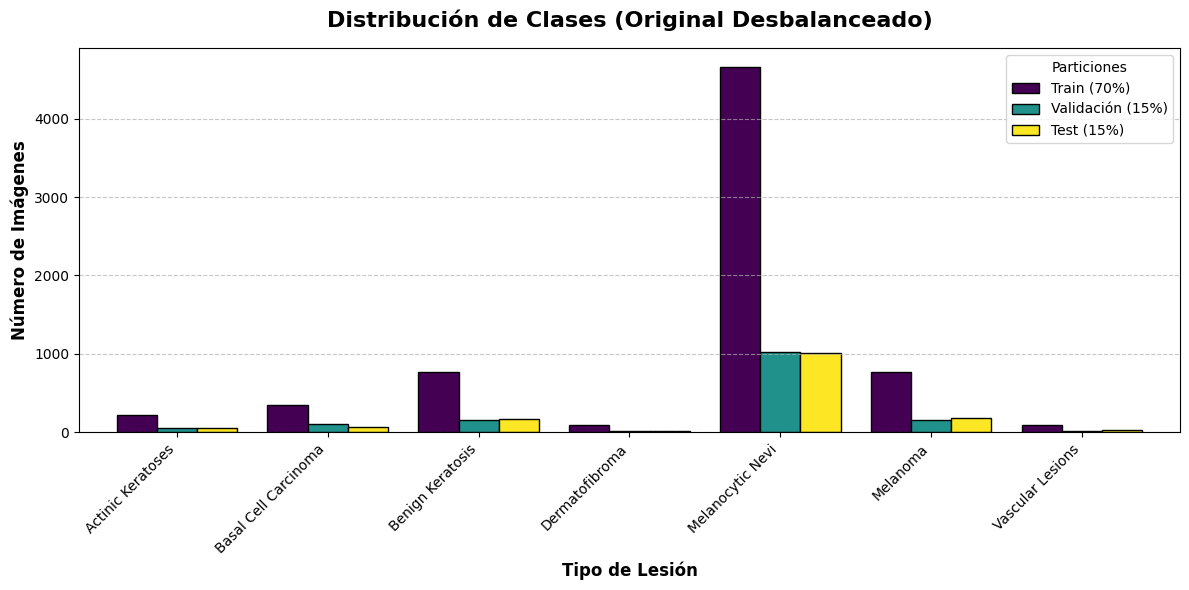

In [ ]:
# 1. Contar las ocurrencias de cada clase en cada partición
train_counts = pd.Series(train_labels).value_counts().sort_index()
val_counts = pd.Series(val_labels).value_counts().sort_index()
test_counts = pd.Series(test_labels).value_counts().sort_index()

# 2. Crear un DataFrame resumen para verlo bonito
dist_df = pd.DataFrame({
    'Train (70%)': train_counts,
    'Validación (15%)': val_counts,
    'Test (15%)': test_counts
})

# Reemplazamos el índice numérico (0 al 6) por los nombres reales de las carpetas
dist_df.index = class_names

print("📊 Distribución exacta de muestras por partición:")
display(dist_df) # 'display' lo formatea como una tabla bonita en Jupyter

print("-" * 60)
print(f"Totales -> Train: {len(train_labels)} | Val: {len(val_labels)} | Test: {len(test_labels)}")

# 3. Visualización Gráfica
plt.figure(figsize=(12, 6))
dist_df.plot(kind='bar', figsize=(12, 6), width=0.8, colormap='viridis', edgecolor='black')

plt.title('Distribución de Clases (Original Desbalanceado)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Tipo de Lesión', fontsize=12, fontweight='bold')
plt.ylabel('Número de Imágenes', fontsize=12, fontweight='bold')

# Rotar los nombres para que se lean bien
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Particiones')

plt.tight_layout()
plt.show()

<class 'pandas.core.frame.DataFrame'>
Index: 10015 entries, ISIC_0027419 to ISIC_0032258
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   dx            10015 non-null  object 
 2   dx_type       10015 non-null  object 
 3   age           9958 non-null   float64
 4   sex           10015 non-null  object 
 5   localization  10015 non-null  object 
dtypes: float64(1), object(5)
memory usage: 805.7+ KB
               age
count  9958.000000
mean     51.863828
std      16.968614
min       0.000000
25%      40.000000
50%      50.000000
75%      65.000000
max      85.000000


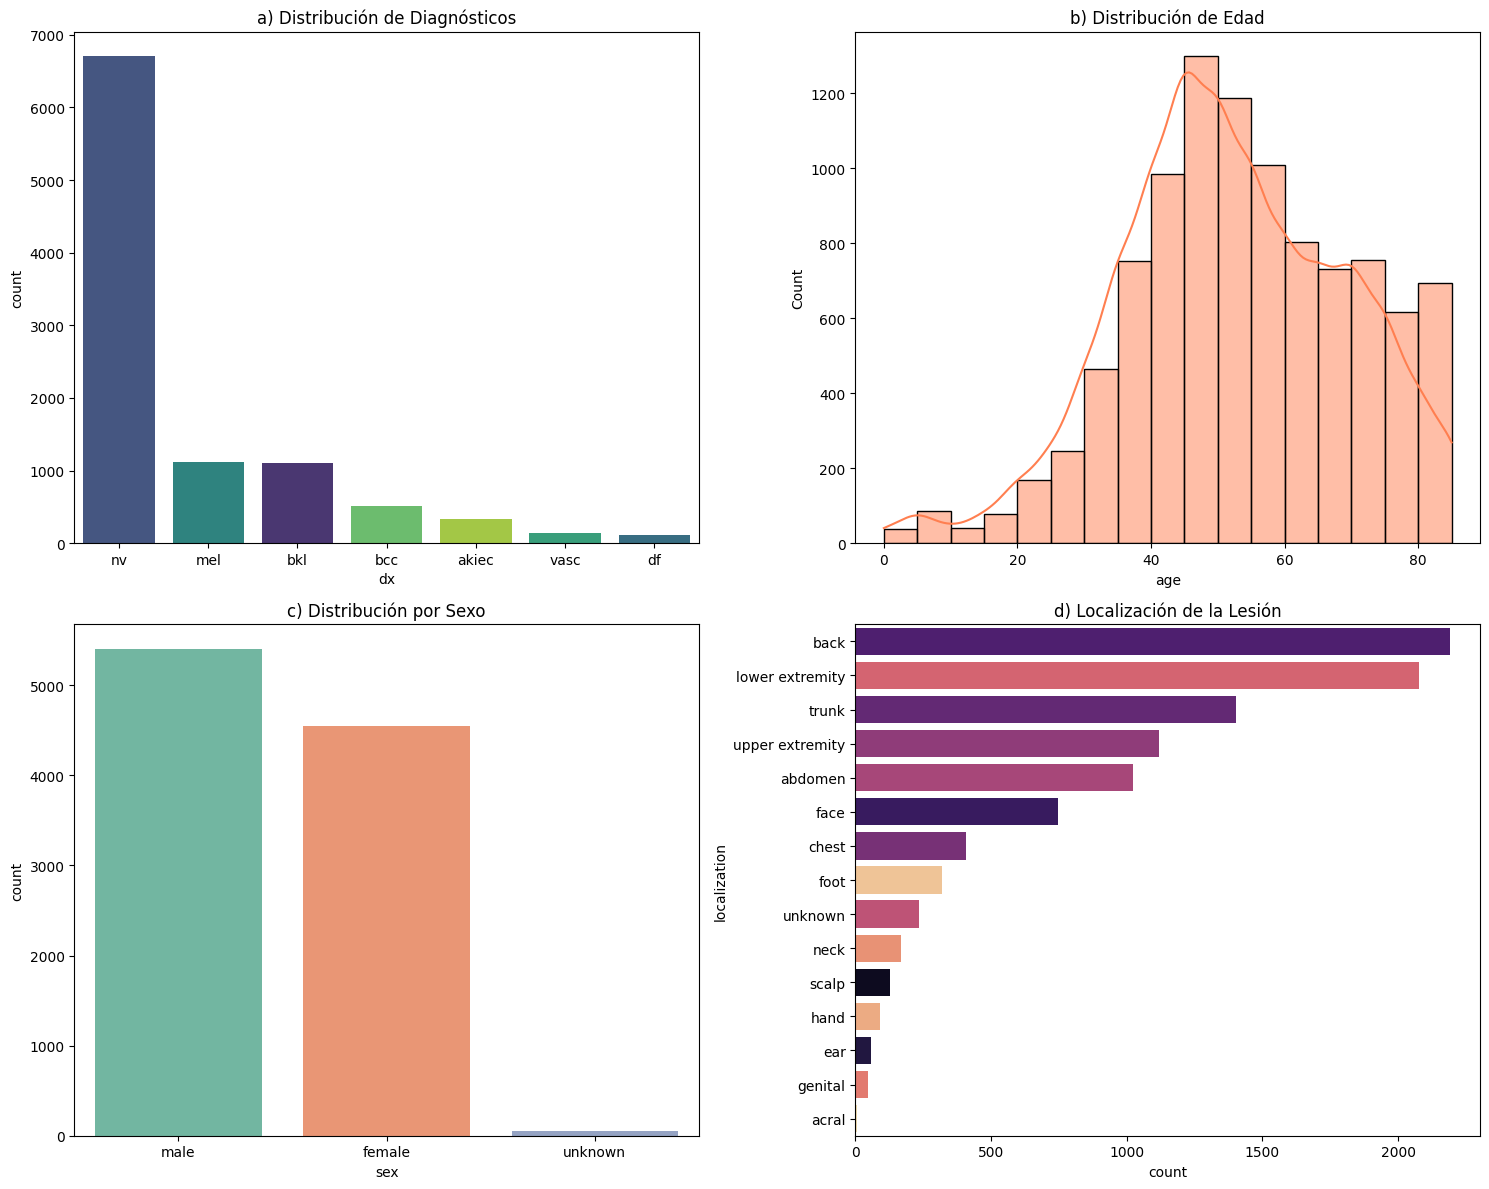

In [8]:
df.info()
print(df.describe())

# Preparamos el lienzo
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Gráfico 1: Diagnóstico (Ordenado para ver el desbalance)
# Solución: Añadimos hue='dx' y legend=False
sns.countplot(data=df, x='dx', hue='dx', order=df['dx'].value_counts().index, ax=axes[0, 0], palette='viridis', legend=False)
axes[0, 0].set_title('a) Distribución de Diagnósticos')

# Gráfico 2: Edad
# Este se queda igual, ya que histplot usa un color único ('color') y no una paleta ('palette')
sns.histplot(data=df, x='age', bins=17, kde=True, ax=axes[0, 1], color='coral')
axes[0, 1].set_title('b) Distribución de Edad')

# Gráfico 3: Sexo
# Solución: Añadimos hue='sex' y legend=False
sns.countplot(data=df, x='sex', hue='sex', order=df['sex'].value_counts().index, ax=axes[1, 0], palette='Set2', legend=False)
axes[1, 0].set_title('c) Distribución por Sexo')

# Gráfico 4: Localización
# Solución: Como aquí las barras son horizontales (y='localization'), el hue debe ser igual a 'localization'
sns.countplot(data=df, y='localization', hue='localization', order=df['localization'].value_counts().index, ax=axes[1, 1], palette='magma', legend=False)
axes[1, 1].set_title('d) Localización de la Lesión')

plt.tight_layout()
plt.show()

In [9]:
print("--- 1. RECUENTO DE VALORES ÚNICOS ---")
# nunique() nos dice cuántas opciones distintas hay por cada columna
print(df.nunique())

print("\n--- 2. ¿QUÉ HAY DENTRO DE LAS CATEGORÍAS? ---")
# Para las variables de texto, a veces queremos ver exactamente cuáles son esas opciones
columnas_interes = ['dx', 'dx_type', 'sex']
for col in columnas_interes:
    print(f"\nValores únicos en '{col}':")
    print(df[col].unique())

print("\n--- 3. DUPLICADOS ---")
# Primero, buscamos si hay filas donde ABSOLUTAMENTE TODO sea idéntico
filas_clonadas = df.duplicated().sum()
print(f"Filas 100% duplicadas (errores de registro): {filas_clonadas}")

# Y ahora, el detalle vital del HAM10000:
# ¿Hay alguna foto repetida? ¿Y cuántas pecas tienen múltiples fotos?
# FIXME: ARREGLAR ESTO
# fotos_duplicadas = df['image_id'].duplicated().sum()
lesiones_duplicadas = df['lesion_id'].duplicated().sum()

# print(f"Imágenes con el mismo ID (fotos repetidas): {fotos_duplicadas}")
print(f"Lesiones con el mismo ID (misma lesión, varias fotos): {lesiones_duplicadas}")

--- 1. RECUENTO DE VALORES ÚNICOS ---
lesion_id       7470
dx                 7
dx_type            4
age               18
sex                3
localization      15
dtype: int64

--- 2. ¿QUÉ HAY DENTRO DE LAS CATEGORÍAS? ---

Valores únicos en 'dx':
['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']

Valores únicos en 'dx_type':
['histo' 'consensus' 'confocal' 'follow_up']

Valores únicos en 'sex':
['male' 'female' 'unknown']

--- 3. DUPLICADOS ---
Filas 100% duplicadas (errores de registro): 2543
Lesiones con el mismo ID (misma lesión, varias fotos): 2545


Creamos la función que leerá tanto la imagen como los metadatos

In [10]:
def process_data(image_path, metadata, label):
    # Procesar imagen
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    
    # El modelo esperará un diccionario o una tupla de entradas: (imagen, metadatos)
    return (img, metadata), tf.one_hot(label, depth=7)

# Dataset de Entrenamiento
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_meta, train_labels))
train_ds = train_ds.shuffle(len(train_paths))
train_ds = train_ds.map(process_data, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Dataset de Validación
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_meta, val_labels))
val_ds = val_ds.map(process_data, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

class_names_es = get_class_name_es(class_names)

print(f"✅ Clases detectadas (IDs): {class_names}")
print(f"🇪🇸 Traducción: {class_names_es}")


# Optimización para la GPU (Crucial para no tener cuellos de botella)
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


✅ Clases detectadas (IDs): ['Actinic Keratoses', 'Basal Cell Carcinoma', 'Benign Keratosis', 'Dermatofibroma', 'Melanocytic Nevi', 'Melanoma', 'Vascular Lesions']
🇪🇸 Traducción: ['Queratosis actínica', 'Carcinoma basocelular', 'Queratosis benigna', 'Dermatofibroma', 'Nevus melanocítico', 'Melanoma', 'Lesión vascular']


## 5: Visualización de muestras

📸 Generando galería de presentación (un ejemplo por clase)...


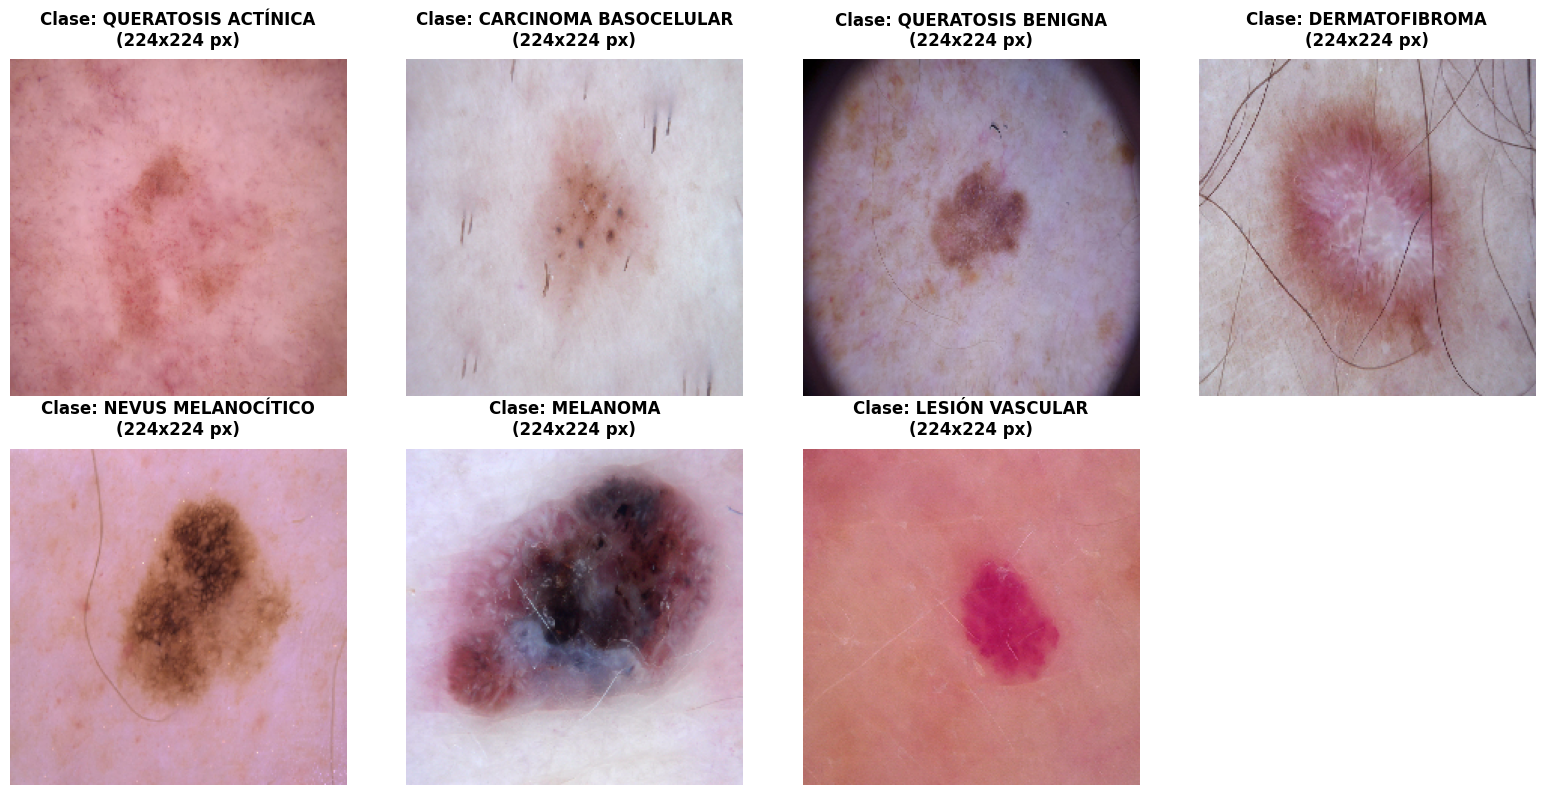

In [11]:
# Configuración de la galería
plt.figure(figsize=(16, 8))
cols = 4
rows = (len(class_names) + cols - 1) // cols

print("📸 Generando galería de presentación (un ejemplo por clase)...")

for i, class_name in enumerate(sorted(class_names)):
    # Ruta a la carpeta de la clase
    class_path = os.path.join(DATA_PATH, class_name)
    # Tomamos la primera imagen que encontremos
    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)
    
    # Cargar y procesar imagen para mostrar
    img = keras.utils.load_img(img_path, target_size=IMG_SIZE)
    img_array = keras.utils.img_to_array(img).astype("uint8")
    
    ax = plt.subplot(rows, cols, i + 1)
    plt.imshow(img_array)
    
    # Título elegante con Nombre y Resolución
    plt.title(f"Clase: {get_class_name_es(class_name).upper()}\n({IMG_SIZE[0]}x{IMG_SIZE[1]} px)", 
              fontsize=12, fontweight='bold', pad=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

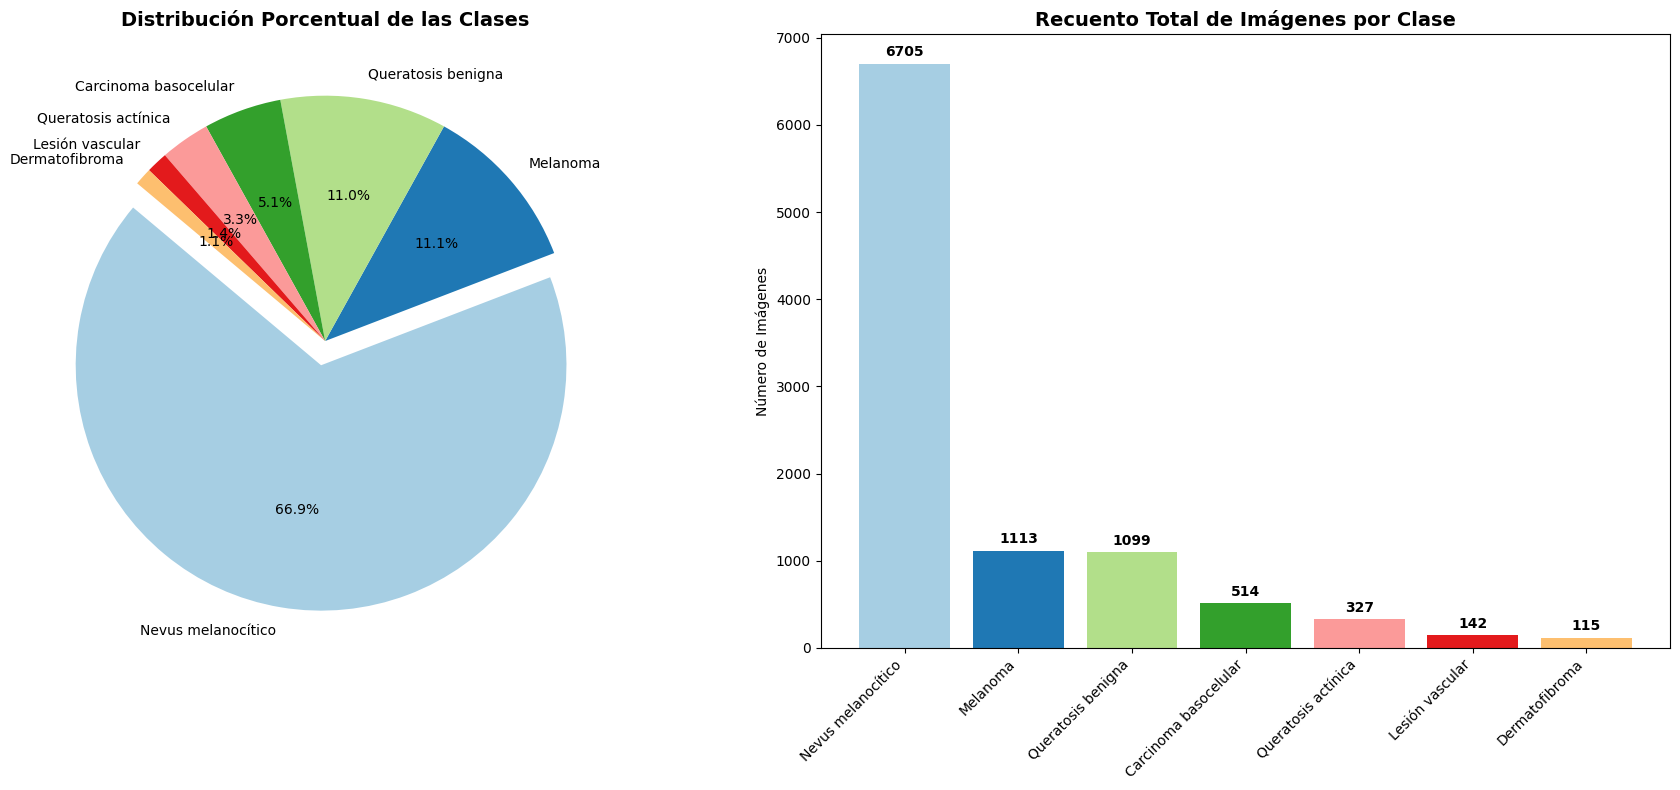


📋 Resumen Estadístico del Dataset (en español):
                 Tipo  Cantidad  Porcentaje
   Nevus melanocítico      6705       66.95
             Melanoma      1113       11.11
   Queratosis benigna      1099       10.97
Carcinoma basocelular       514        5.13
  Queratosis actínica       327        3.27
      Lesión vascular       142        1.42
       Dermatofibroma       115        1.15


In [12]:
# 1. Contar archivos por carpeta
stats = {}
for class_name in class_names:
    class_path = os.path.join(DATA_PATH, class_name)
    stats[class_name] = len(os.listdir(class_path))

# 2. Crear DataFrame y TRADUCIR
df_stats = pd.DataFrame(list(stats.items()), columns=['Tipo', 'Cantidad'])

# --- APLICAMOS LA TRADUCCIÓN AQUÍ ---
df_stats['Tipo'] = df_stats['Tipo'].apply(get_class_name_es)
# ------------------------------------

df_stats = df_stats.sort_values(by='Cantidad', ascending=False)
df_stats['Porcentaje'] = (df_stats['Cantidad'] / df_stats['Cantidad'].sum() * 100).round(2)

# 3. Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8)) # Aumentado un poco el alto

# Gráfico de Tarta
colors = plt.cm.Paired(range(len(class_names)))
wedges, texts, autotexts = ax1.pie(df_stats['Cantidad'], labels=df_stats['Tipo'], 
                                   autopct='%1.1f%%', startangle=140, colors=colors,
                                   explode=[0.1 if i == 0 else 0 for i in range(len(df_stats))])
ax1.set_title("Distribución Porcentual de las Clases", fontsize=14, fontweight='bold')

# Gráfico de Barras
bars = ax2.bar(df_stats['Tipo'], df_stats['Cantidad'], color=colors)
ax2.set_title("Recuento Total de Imágenes por Clase", fontsize=14, fontweight='bold')
ax2.set_ylabel("Número de Imágenes")

# Rotar etiquetas para que no se solapen los nombres en español
plt.sca(ax2)
plt.xticks(rotation=45, ha='right')

# Añadir etiquetas de cantidad sobre las barras
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 50, yval, ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Mostrar tabla resumen
print("\n📋 Resumen Estadístico del Dataset (en español):")
print(df_stats.to_string(index=False))

## 5: Búsqueda de hiperparámetros

Primero configuramos Optuna como optimizador:

In [13]:
storage_name = "sqlite:///optuna_tfm.db"
print(f"✅ Optuna DB lista en {storage_name}")

✅ Optuna DB lista en sqlite:///optuna_tfm.db


In [ ]:
MODEL_NAME = "ResNet50"
STUDY_NAME = "DataAugmentation_FL_alpha_2"
print(f"🚀 Lanzando estudio de Optuna: {STUDY_NAME}")
mixed_precision.set_global_policy("mixed_float16")


pesos_balanceados = compute_class_weight(
    class_weight='balanced', 
    classes=np.unique(train_labels), 
    y=train_labels
)

alpha_weights = list(pesos_balanceados.astype(np.float32))
# alpha_weights[0] *= 1.2 
# alpha_weights[1] *= 1.2 
# alpha_weights[5] *= 1.5 

# Segundo conjunto de pesos ajustados para comparar
alpha_weights[0] *= 1.2 # Darle un 20% más de importancia a la Queratosis Actínica
alpha_weights[1] *= 1.4 # Darle un 40% más de importancia al BCC
alpha_weights[5] *= 1.5 # Darle un 50% más de importancia al Melanoma
alpha_weights[3] *= 0.5  # Dividimos su penalización a la mitad


print("📊 Pesos calculados para cada clase (Alpha):")
for i, peso in enumerate(alpha_weights):
    print(f"Clase {i}: {peso:.4f}")


class TimestampCallback(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        hora_actual = datetime.datetime.now().strftime("%H:%M:%S")
        print(f"\n⏰ Inicio Época {epoch + 1}: {hora_actual}")

    def on_epoch_end(self, epoch, logs=None):
        hora_actual = datetime.datetime.now().strftime("%H:%M:%S")
        print(f"✅ Fin Época {epoch + 1}: {hora_actual}")

def objective(trial):
    try:
        # 1. Limpiar memoria del Trial anterior CRÍTICO
        tf.keras.backend.clear_session()
        gc.collect()

        # 1. HIPERPARÁMETROS
        lr = trial.suggest_float("learning_rate", 1e-5, 5e-4, log=True)
        dropout = trial.suggest_float("dropout", 0.2, 0.5)
        meta_units = trial.suggest_int("meta_units", 16, 32)
        meta_layers = trial.suggest_int("meta_layers", 1, 3)
        
        # 2. DATA AUGMENTATION
        zoom_factor = 0.10
        rotation_prob = 0.5

        # Capa nativa de Keras para Zoom aleatorio
        zoom_layer = tf.keras.layers.RandomZoom(
            height_factor=(-zoom_factor, 0.0), 
            width_factor=(-zoom_factor, 0.0)
        )

        def augment_fn(image):
            # La rotación en múltiplos de 90º mantiene la forma original (224x224), es 100% segura
            if tf.random.uniform([]) < rotation_prob:
                image = tf.image.rot90(image, k=tf.random.uniform([], 0, 4, tf.int32))
            
            # Usamos la capa de Keras (que exige un batch dimension temporal)
            if zoom_factor > 0:
                image = tf.expand_dims(image, 0) # Añadir fake batch: (1, 224, 224, 3)
                image = zoom_layer(image)
                image = tf.squeeze(image, 0)     # Quitar fake batch: (224, 224, 3)
                
            return image

        # 3. PIPELINE
        train_ds_aug = tf.data.Dataset.from_tensor_slices((train_paths, train_meta, train_labels))
        train_ds_aug = train_ds_aug.shuffle(2000).map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
        train_ds_aug = train_ds_aug.map(
            lambda inputs, label: ((augment_fn(inputs[0]), inputs[1]), label),
            num_parallel_calls=tf.data.AUTOTUNE
        ).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

        # 4. MODELO
        input_img = layers.Input(shape=(224, 224, 3), name="image_input")
        
        # Nota: Poner trainable=True desde el inicio con un pre-entrenado es agresivo, 
        # pero como Optuna busca LRs muy bajos (1e-5), puede funcionar bien.
        #base_model = coatnet.CoAtNet0(
        #    input_shape=(224, 224, 3), num_classes=0, pretrained="imagenet"
        #)

        base_model = ResNet50(
            weights='imagenet',
            include_top=False,
            input_shape=(224, 224, 3)
        )

        base_model.trainable = False
        img_features = layers.GlobalAveragePooling2D()(base_model(input_img))

        input_meta = layers.Input(shape=(19,), name="meta_input")
        x_meta = input_meta
        for i in range(meta_layers):
            x_meta = layers.Dense(meta_units, activation="relu")(x_meta)
            x_meta = layers.BatchNormalization()(x_meta)

        combined = layers.Concatenate()([img_features, x_meta])
        x = layers.Dense(256, activation="relu")(combined)
        x = layers.Dropout(dropout)(x)
        output = layers.Dense(7, activation="softmax", dtype="float32")(x)

        model = models.Model(inputs=[input_img, input_meta], outputs=output)
        
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
            loss=tf.keras.losses.CategoricalFocalCrossentropy(alpha=alpha_weights, gamma=2.0),
            metrics=[
                'accuracy',
                tf.keras.metrics.Recall(class_id=4, name='recall_melanoma'),     
                tf.keras.metrics.Recall(class_id=1, name='recall_bcc'),          
                tf.keras.metrics.Recall(class_id=0, name='recall_actinica')      
            ],
        )

        # 5. CALLBACKS DEFINIDOS DENTRO DEL TRIAL
        lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=0
        )
        
        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=8, restore_best_weights=True, verbose=0
        )
        
        timestamp_cb = TimestampCallback()

        # 6. ENTRENAMIENTO
        history = model.fit(
            train_ds_aug,
            validation_data=val_ds, 
            epochs=50, 
            callbacks=[
                lr_scheduler,
                early_stop, # Descomentado, ¡es muy útil para que Optuna vaya rápido!
                timestamp_cb,
                TFKerasPruningCallback(trial, "val_loss") # Podar si la val_loss va mal
            ],
            verbose=0
        )

        # Devolvemos el mínimo de la val_loss (Focal Loss)
        return min(history.history["val_loss"])


    except optuna.exceptions.TrialPruned as e:
        # Silenciar la poda normal de Optuna para que no grite "FUEGO"
        raise e

    except Exception as e:
            # 2. Crash REAL (Out of Memory, error de sintaxis, etc)
            print(f"\n❌ FUEGO! El Trial {trial.number} ha crasheado:")
            print(traceback.format_exc()) 
            raise e
    
    finally:
        # 3. Corrección de la Fuga de Memoria: Limpieza agresiva al final de CADA trial.
        # Este bloque se ejecuta SIEMPRE, ya sea que el trial falle, sea podado o termine bien.
        if 'model' in locals():
            del model
        if 'base_model' in locals():
            del base_model
        if 'train_ds_aug' in locals():
            del train_ds_aug
            
        tf.keras.backend.clear_session()
        gc.collect()

# Lanzar el estudio buscando MINIMIZAR el error
study = optuna.create_study(
    direction="minimize", # IMPORTANTE: Queremos que la pérdida baje
    storage=storage_name, # Asegúrate de que 'storage_name' esté definido antes (ej. "sqlite:///estudio.db")
    study_name=STUDY_NAME, 
    load_if_exists=True
)

🚀 Lanzando estudio de Optuna: DataAugmentation_FL_alpha_2
INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 5060 Laptop GPU, compute capability 12.0
📊 Pesos calculados para cada clase (Alpha):
Clase 0: 5.3768
Clase 1: 3.9903
Clase 2: 1.2918
Clase 3: 5.4061
Clase 4: 0.2132
Clase 5: 1.9352
Clase 6: 10.5821


2026-06-02 16:10:00.646742: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
[I 2026-06-02 16:10:01,036] Using an existing study with name 'DataAugmentation_FL_alpha_2' instead of creating a new one.


Ahora empezamos los trials del entrenamiento. Con el parámetro skip_training a "True" podemos saltarlo y usar el mejor modelo ya entrenado.

In [15]:
optuna.logging.set_verbosity(optuna.logging.DEBUG)

# --- CONFIGURACIÓN DE FLUJO ---
SKIP_TRAINING = True     # True: Carga el modelo | False: Entrena
RUN_OPTIMIZATION = False   # True: Busca mejores parámetros | False: Usa los mejores ya encontrados o defaults
TRAIN_FINAL_MODEL = True  # True: Entrena el modelo final con los mejores parámetros | False: Solo carga
TRIALS = 15                                                                                                     
 
 # 1. EJECUCIÓN DE OPTUNA
if not SKIP_TRAINING and RUN_OPTIMIZATION:
    print(f"🔥 Lanzando optimización con Optuna (n_trials={TRIALS})...")
    study.optimize(objective, n_trials=TRIALS)
    print("✅ Optimización completada.")
    
    # Vaciamos la memoria del último modelo de Optuna para dejar sitio al Modelo Final
    tf.keras.backend.clear_session()
    gc.collect()

# 2. SELECCIÓN DE PARÁMETROS
# Filtramos para ver si hay algún trial que haya terminado con éxito
completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]

if len(completed_trials) > 0:
    best_params = study.best_params
    print(f"📈 Usando mejores parámetros encontrados por Optuna:")
    for key, value in best_params.items():
        print(f"   - {key}: {value}")
else:
    best_params = {
        'learning_rate': 1e-4, 
        'dropout': 0.3, 
        'meta_units': 32,       
        'meta_layers': 2,       
        'zoom_factor': 0.1,     
        'rotation_prob': 0.5    
    }
    print(f"⚠️ No hay historial de éxito en la DB. Usando parámetros por defecto: {best_params}")

📈 Usando mejores parámetros encontrados por Optuna:
   - learning_rate: 2.817005895747344e-05
   - dropout: 0.22448188132715313
   - meta_units: 25
   - meta_layers: 2


## 7. Entrenamiento del modelo final

In [16]:
MODEL_PATH = f'models/{STUDY_NAME}.keras' # Ojo: he quitado la barra inicial (/) para que no intente guardar en la raíz del disco duro

if TRAIN_FINAL_MODEL:
    # 1. Recuperar los mejores parámetros (Solo los que Optuna optimizó)
    if 'best_params' not in locals():
        best_params = {
            'learning_rate': 1e-4, 'dropout': 0.3, 'meta_units': 32, 'meta_layers': 2
        }
    print(f"🏆 Mejores parámetros a usar: {best_params}")

    # ==========================================
    # APLICAR EL DATA AUGMENTATION FIJO (HARDCODED)
    # ==========================================
    FINAL_ZOOM_FACTOR = 0.10
    FINAL_ROTATION_PROB = 0.5
    
    # Capa anti-OOM de Keras
    zoom_layer = tf.keras.layers.RandomZoom(
        height_factor=(-FINAL_ZOOM_FACTOR, 0.0), 
        width_factor=(-FINAL_ZOOM_FACTOR, 0.0)
    )

    def final_augment_fn(image):
        if tf.random.uniform([]) < FINAL_ROTATION_PROB:
            image = tf.image.rot90(image, k=tf.random.uniform([], 0, 4, tf.int32))
            
        if FINAL_ZOOM_FACTOR > 0:
            image = tf.expand_dims(image, 0) # Añadir fake batch
            image = zoom_layer(image)
            image = tf.squeeze(image, 0)     # Quitar fake batch
            
        return image

    print("🔄 Generando Dataset Final con Data Augmentation...")
    train_ds_final = tf.data.Dataset.from_tensor_slices((train_paths, train_meta, train_labels))
    train_ds_final = train_ds_final.shuffle(len(train_paths)).map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
    train_ds_final = train_ds_final.map(
        lambda inputs, label: ((final_augment_fn(inputs[0]), inputs[1]), label),
        num_parallel_calls=tf.data.AUTOTUNE
    ).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    # ==========================================
    # 2. Reconstruir la arquitectura híbrida con ResNet50
    # ==========================================
    input_img = layers.Input(shape=(224, 224, 3), name="image_input")
    input_meta = layers.Input(shape=(19,), name="meta_input")

    # --- Rama de imagen: ResNet50 ---
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False  # Congelado para la fase inicial

    img_output = base_model(input_img, training=False)
    img_features = layers.GlobalAveragePooling2D()(img_output)

    # --- Rama de metadatos ---
    x_meta = input_meta
    for _ in range(best_params['meta_layers']):
        x_meta = layers.Dense(best_params['meta_units'], activation="relu")(x_meta)
        x_meta = layers.BatchNormalization()(x_meta)

    # --- Fusión ---
    combined = layers.Concatenate()([img_features, x_meta])
    x = layers.Dense(256, activation="relu")(combined)
    x = layers.Dropout(best_params['dropout'])(x)
    output = layers.Dense(7, activation="softmax", dtype="float32")(x)

    final_model = models.Model(inputs=[input_img, input_meta], outputs=output)

    # ==========================================
    # 3. Compilar — FASE 1: Solo cabeza clasificadora
    # ==========================================
    final_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.CategoricalFocalCrossentropy(
            alpha=alpha_weights, gamma=2.0
        ),
        metrics=[
            "accuracy",
            tf.keras.metrics.Recall(class_id=4, name='recall_melanoma'),
            tf.keras.metrics.Recall(class_id=1, name='recall_bcc'),
            tf.keras.metrics.Recall(class_id=0, name='recall_actinica')
        ],
        jit_compile=False
    )

    final_model.summary()

    # ==========================================
    # 4. Entrenamiento — FASE 1
    # ==========================================
    INITIAL_EPOCHS = 5

    callbacks_phase1 = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )
    ]

    print("🔒 Fase 1: Entrenando solo la cabeza clasificadora...")
    history_initial = final_model.fit(
        train_ds_final,
        validation_data=val_ds,
        epochs=INITIAL_EPOCHS,
        callbacks=callbacks_phase1
    )

    # ==========================================
    # 5. Fine-Tuning — FASE 2: Descongelar ResNet50 parcialmente
    # ==========================================
    base_model.trainable = True

    # Congelar las primeras 140 capas (capas bajas = características genéricas)
    FINE_TUNE_AT = 140
    for layer in base_model.layers[:FINE_TUNE_AT]:
        layer.trainable = False

    # Mantener BatchNormalization siempre congelado
    for layer in base_model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    # Recompilar con learning rate pequeño
    final_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss=tf.keras.losses.CategoricalFocalCrossentropy(
            alpha=alpha_weights, gamma=2.0
        ),
        metrics=[
            "accuracy",
            tf.keras.metrics.Recall(class_id=4, name='recall_melanoma'),
            tf.keras.metrics.Recall(class_id=1, name='recall_bcc'),
            tf.keras.metrics.Recall(class_id=0, name='recall_actinica')
        ],
        jit_compile=False
    )

    # ==========================================
    # 6. Entrenamiento — FASE 2
    # ==========================================
    FINE_TUNE_EPOCHS = 55  # Total = 5 + 55 = 60 épocas máximas
    TOTAL_EPOCHS = INITIAL_EPOCHS + FINE_TUNE_EPOCHS

    callbacks_phase2 = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=MODEL_PATH,
            monitor='val_loss',
            save_best_only=True,
            mode='min',
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.2, patience=4, min_lr=1e-6, verbose=1
        )
    ]

    print("🚀 Fase 2: Fine-tuning del modelo definitivo...")
    history_finetune = final_model.fit(
        train_ds_final,
        validation_data=val_ds,
        epochs=TOTAL_EPOCHS,
        initial_epoch=history_initial.epoch[-1] + 1,
        callbacks=callbacks_phase2
    )
    
    final_model.save("models/modelo_tfm_balanceado_backup.keras")

else:
    if os.path.exists(MODEL_PATH):
        print(f"📦 Cargando modelo final desde {MODEL_PATH}...")
        final_model = tf.keras.models.load_model(
            MODEL_PATH, 
            custom_objects={"CategoricalFocalCrossentropy": tf.keras.losses.CategoricalFocalCrossentropy}
        )
    else:
        print(f"❌ ERROR: TRAIN_FINAL_MODEL es False pero no encuentro {MODEL_PATH}")

🏆 Mejores parámetros a usar: {'learning_rate': 2.817005895747344e-05, 'dropout': 0.22448188132715313, 'meta_units': 25, 'meta_layers': 2}
🔄 Generando Dataset Final con Data Augmentation...
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 meta_input (InputLayer)     [(None, 19)]                 0         []                            
                                                                                                  
 dense (Dense)               (None, 25)                   500       ['meta_input[0][0]']          
                                                                                                  
 image_input (InputLayer)    [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 bat

2026-06-02 16:10:06.961072: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-06-02 16:10:06.983784: W external/local_xla/xla/stream_executor/gpu/asm_compiler.cc:225] Falling back to the CUDA driver for PTX compilation; ptxas does not support CC 12.0
2026-06-02 16:10:06.983891: W external/local_xla/xla/stream_executor/gpu/asm_compiler.cc:228] Used ptxas at /home/jesus/repos/TFM/.venv/lib/python3.11/site-packages/tensorflow/python/platform/../../../nvidia/cuda_nvcc/bin/ptxas
2026-06-02 16:10:06.984176: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-06-02 16:10:06.984230: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-06-02 16:10:07.151552: I external/local_xla/

218/218 [==============================] - 58s 136ms/step - loss: 1.4398 - accuracy: 0.2763 - recall_melanoma: 0.0079 - recall_bcc: 0.0029 - recall_actinica: 0.0045 - val_loss: 1.3696 - val_accuracy: 0.3187 - val_recall_melanoma: 0.0000e+00 - val_recall_bcc: 0.0000e+00 - val_recall_actinica: 0.0000e+00
Epoch 2/5
218/218 [==============================] - 25s 114ms/step - loss: 1.2512 - accuracy: 0.3099 - recall_melanoma: 0.0028 - recall_bcc: 0.0000e+00 - recall_actinica: 0.0000e+00 - val_loss: 1.3043 - val_accuracy: 0.1875 - val_recall_melanoma: 0.0000e+00 - val_recall_bcc: 0.0000e+00 - val_recall_actinica: 0.0000e+00
Epoch 3/5
218/218 [==============================] - 25s 116ms/step - loss: 1.2175 - accuracy: 0.2792 - recall_melanoma: 0.0066 - recall_bcc: 0.0000e+00 - recall_actinica: 0.0000e+00 - val_loss: 1.2506 - val_accuracy: 0.0997 - val_recall_melanoma: 0.0000e+00 - val_recall_bcc: 0.0000e+00 - val_recall_actinica: 0.0000e+00
Epoch 4/5
218/218 [==============================] -

## 8: Predicciones
En esta celda extraemos las etiquetas reales y generamos las predicciones del modelo sobre el set de validación.

In [17]:
def get_predictions(dataset, name=""):
    print(f"🔮 Generando predicciones sobre el set de {name}...")
    y_true = []
    y_pred = []
    
    # Iteramos sobre el dataset para obtener imágenes, metadatos y etiquetas reales
    for (images, meta), labels in dataset:
        # Predicción del modelo híbrido
        preds = final_model.predict((images, meta), verbose=0)
        
        # Guardamos la realidad (argmax de one-hot) y la predicción
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))
        
    return np.array(y_true), np.array(y_pred)

# Definimos el nombre del archivo donde vivirán las variables
ARCHIVO_PREDICCIONES = "predicciones_modelo_hibrido.npz"

if TRAIN_FINAL_MODEL:
    # 1. Generamos las de ENTRENAMIENTO
    y_true_train, y_pred_train = get_predictions(train_ds, name="ENTRENAMIENTO")

    # 2. Generamos las de VALIDACIÓN
    y_true_val, y_pred_val = get_predictions(val_ds, name="VALIDACIÓN")

    # 3. Generamos las de TEST
    y_true_test, y_pred_test = get_predictions(test_ds, name="TEST")
    
    # --- GUARDAMOS LAS VARIABLES EN DISCO ---
    np.savez(ARCHIVO_PREDICCIONES, 
             y_true_train=y_true_train, y_pred_train=y_pred_train,
             y_true_val=y_true_val, y_pred_val=y_pred_val,
             y_true_test=y_true_test, y_pred_test=y_pred_test)
    
    print(f"✅ Predicciones guardadas correctamente en '{ARCHIVO_PREDICCIONES}'")
    print(f"📊 Análisis completado. Entrenamiento: {len(y_true_train)} imágenes | Validación: {len(y_true_val)} imágenes | Test: {len(y_true_test)} imágenes.")

else:
    # --- CARGAMOS LAS VARIABLES DESDE EL DISCO ---
    if os.path.exists(ARCHIVO_PREDICCIONES):
        print(f"📦 Cargando predicciones previas desde '{ARCHIVO_PREDICCIONES}'...")
        datos = np.load(ARCHIVO_PREDICCIONES)
        
        # Extraemos las variables para que estén disponibles en el entorno
        y_true_train = datos['y_true_train']
        y_pred_train = datos['y_pred_train']
        y_true_val   = datos['y_true_val']
        y_pred_val   = datos['y_pred_val']
        y_true_test  = datos['y_true_test']
        y_pred_test  = datos['y_pred_test']
        
        print(f"✅ Predicciones cargadas en memoria con éxito.")
        print(f"📊 Datos listos. Entrenamiento: {len(y_true_train)} imágenes | Validación: {len(y_true_val)} imágenes | Test: {len(y_true_test)} imágenes.")
        
    else:
        print(f"⚠️ No se encontró el archivo '{ARCHIVO_PREDICCIONES}'. Generándolas sobre la marcha...")
        # Generación de emergencia si falta el archivo
        y_true_train, y_pred_train = get_predictions(train_ds, name="ENTRENAMIENTO")
        y_true_val, y_pred_val     = get_predictions(val_ds, name="VALIDACIÓN")
        y_true_test, y_pred_test   = get_predictions(test_ds, name="TEST")

🔮 Generando predicciones sobre el set de ENTRENAMIENTO...


2026-06-02 16:21:48.137766: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:25: Filling up shuffle buffer (this may take a while): 169 of 1000
2026-06-02 16:21:48.948787: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] Shuffle buffer filled.


🔮 Generando predicciones sobre el set de VALIDACIÓN...
🔮 Generando predicciones sobre el set de TEST...
✅ Predicciones guardadas correctamente en 'predicciones_modelo_hibrido.npz'
📊 Análisis completado. Entrenamiento: 6963 imágenes | Validación: 1525 imágenes | Test: 1527 imágenes.


## 9: Métricas Globales y por Clase

Aquí verás el rendimiento del entrenamiento (si lo hubo) y el reporte detallado (Precisión, Recall, F1-Score) por cada tipo de lesión.

In [18]:
acc_train = accuracy_score(y_true_train, y_pred_train)
acc_val = accuracy_score(y_true_val, y_pred_val)
acc_test = accuracy_score(y_true_test, y_pred_test)

reporte_md = f"""

# Modelo {MODEL_NAME} - Estudio: {STUDY_NAME}

============================================================
RENDIMIENTO GLOBAL
   - Accuracy Entrenamiento: {acc_train:.4f}
   - Accuracy Validación:    {acc_val:.4f}
   - Accuracy Test:          {acc_test:.4f}
============================================================

## 📋 REPORTE DETALLADO POR CLASE (SET DE TEST):
{classification_report(y_true_test, y_pred_test, target_names=class_names_es)}

## 📋 REPORTE DETALLADO POR CLASE (SET DE VALIDACIÓN):
{classification_report(y_true_val, y_pred_val, target_names=class_names_es)}

## 📋 REPORTE DETALLADO POR CLASE (SET DE ENTRENAMIENTO):
{classification_report(y_true_train, y_pred_train, target_names=class_names_es)}
"""

print(reporte_md)

os.makedirs('results', exist_ok=True)
ruta_archivo = f"results/{STUDY_NAME}.md"

with open(ruta_archivo, "w", encoding="utf-8") as f:
    f.write(reporte_md)

print(f"💾 Reporte guardado exitosamente en: {ruta_archivo}")




# Modelo CoAtNet0 - Estudio: DataAugmentation_FL_alpha_2

RENDIMIENTO GLOBAL
   - Accuracy Entrenamiento: 0.3256
   - Accuracy Validación:    0.3213
   - Accuracy Test:          0.3202

## 📋 REPORTE DETALLADO POR CLASE (SET DE TEST):
                       precision    recall  f1-score   support

  Queratosis actínica       0.14      0.52      0.22        48
Carcinoma basocelular       0.14      0.44      0.21        66
   Queratosis benigna       0.36      0.05      0.09       172
       Dermatofibroma       0.02      0.30      0.03        10
   Nevus melanocítico       0.92      0.34      0.50      1016
             Melanoma       0.22      0.38      0.28       186
      Lesión vascular       0.03      0.24      0.06        29

             accuracy                           0.32      1527
            macro avg       0.26      0.32      0.20      1527
         weighted avg       0.69      0.32      0.39      1527


## 📋 REPORTE DETALLADO POR CLASE (SET DE VALIDACIÓN):
             

## 10: Matriz de Confusión

Esta es la gráfica visual definitiva para ver dónde se "equivoca" el modelo (por ejemplo, si confunde Melanoma con Nevus).

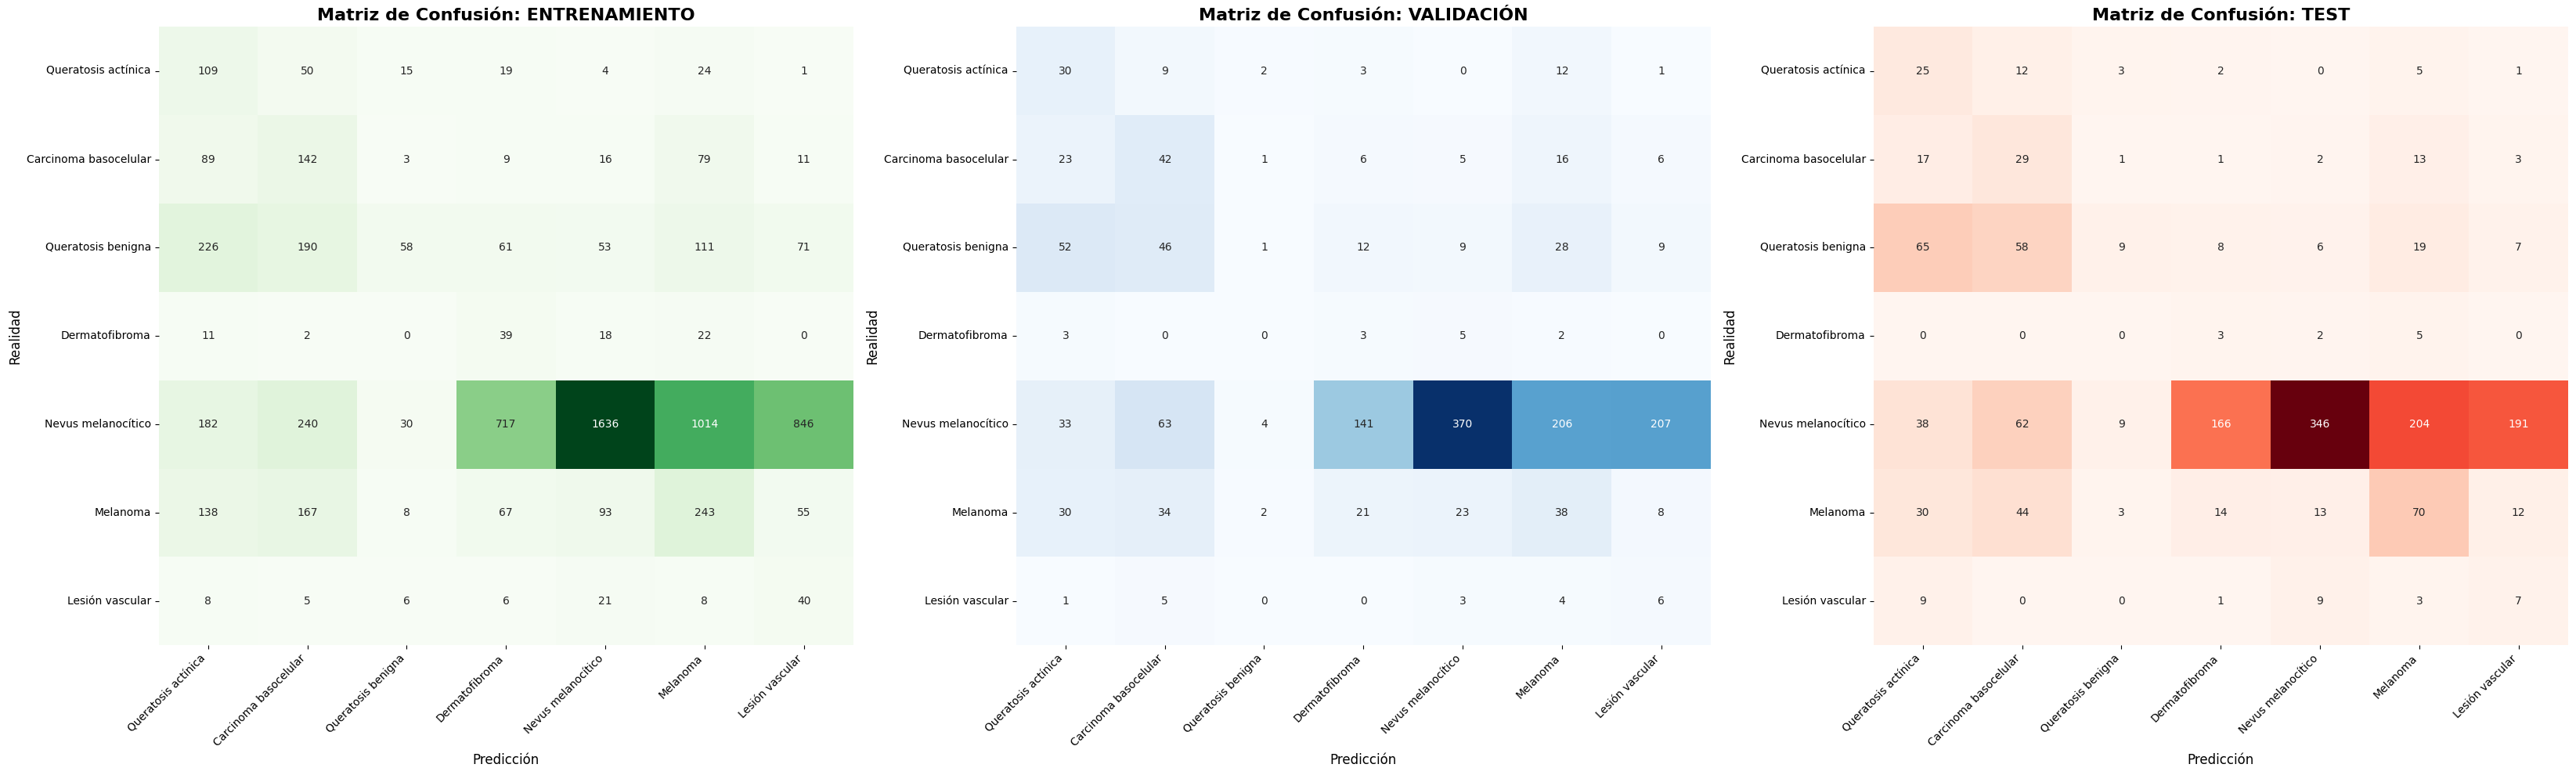

In [19]:


# 1. Calculamos las matrices (la lógica sigue igual)
cm_train = confusion_matrix(y_true_train, y_pred_train)
cm_val = confusion_matrix(y_true_val, y_pred_val)
cm_test = confusion_matrix(y_true_test, y_pred_test)
# 2. Configuramos el gráfico
fig, ax = plt.subplots(1, 3, figsize=(33, 10)) # Aumentamos un poco el tamaño

# Matriz de Entrenamiento (Verde)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens', ax=ax[0],
            xticklabels=class_names_es, yticklabels=class_names_es,
            cbar=False) # Quitamos la barra lateral para ganar espacio
ax[0].set_title('Matriz de Confusión: ENTRENAMIENTO', fontsize=16, fontweight='bold')
ax[0].set_xlabel('Predicción', fontsize=12)
ax[0].set_ylabel('Realidad', fontsize=12)

# Matriz de Validación (Azul)
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', ax=ax[1],
            xticklabels=class_names_es, yticklabels=class_names_es,
            cbar=False)
ax[1].set_title('Matriz de Confusión: VALIDACIÓN', fontsize=16, fontweight='bold')
ax[1].set_xlabel('Predicción', fontsize=12)
ax[1].set_ylabel('Realidad', fontsize=12)

# Matriz de Test (Roja)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Reds', ax=ax[2],
            xticklabels=class_names_es, yticklabels=class_names_es,
            cbar=False)
ax[2].set_title('Matriz de Confusión: TEST', fontsize=16, fontweight='bold')
ax[2].set_xlabel('Predicción', fontsize=12)
ax[2].set_ylabel('Realidad', fontsize=12)

# --- AJUSTE CRÍTICO DE ETIQUETAS ---
# Rotamos las etiquetas de las X para que no se pisen
for a in ax:
    plt.sca(a)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## 11: Inteligencia Artificial Explicable (XAI) - Grad-CAM
En esta sección visualizamos en qué regiones de la imagen se fija el modelo para clasificar las lesiones.


🚀 Generando tabla de: Aciertos del Modelo...


2026-06-02 16:28:13.976931: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-06-02 16:28:13.977056: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-06-02 16:28:13.977103: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-06-02 16:28:13.977158: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-06-02 16:28:13.977224: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-06-02

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/198 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

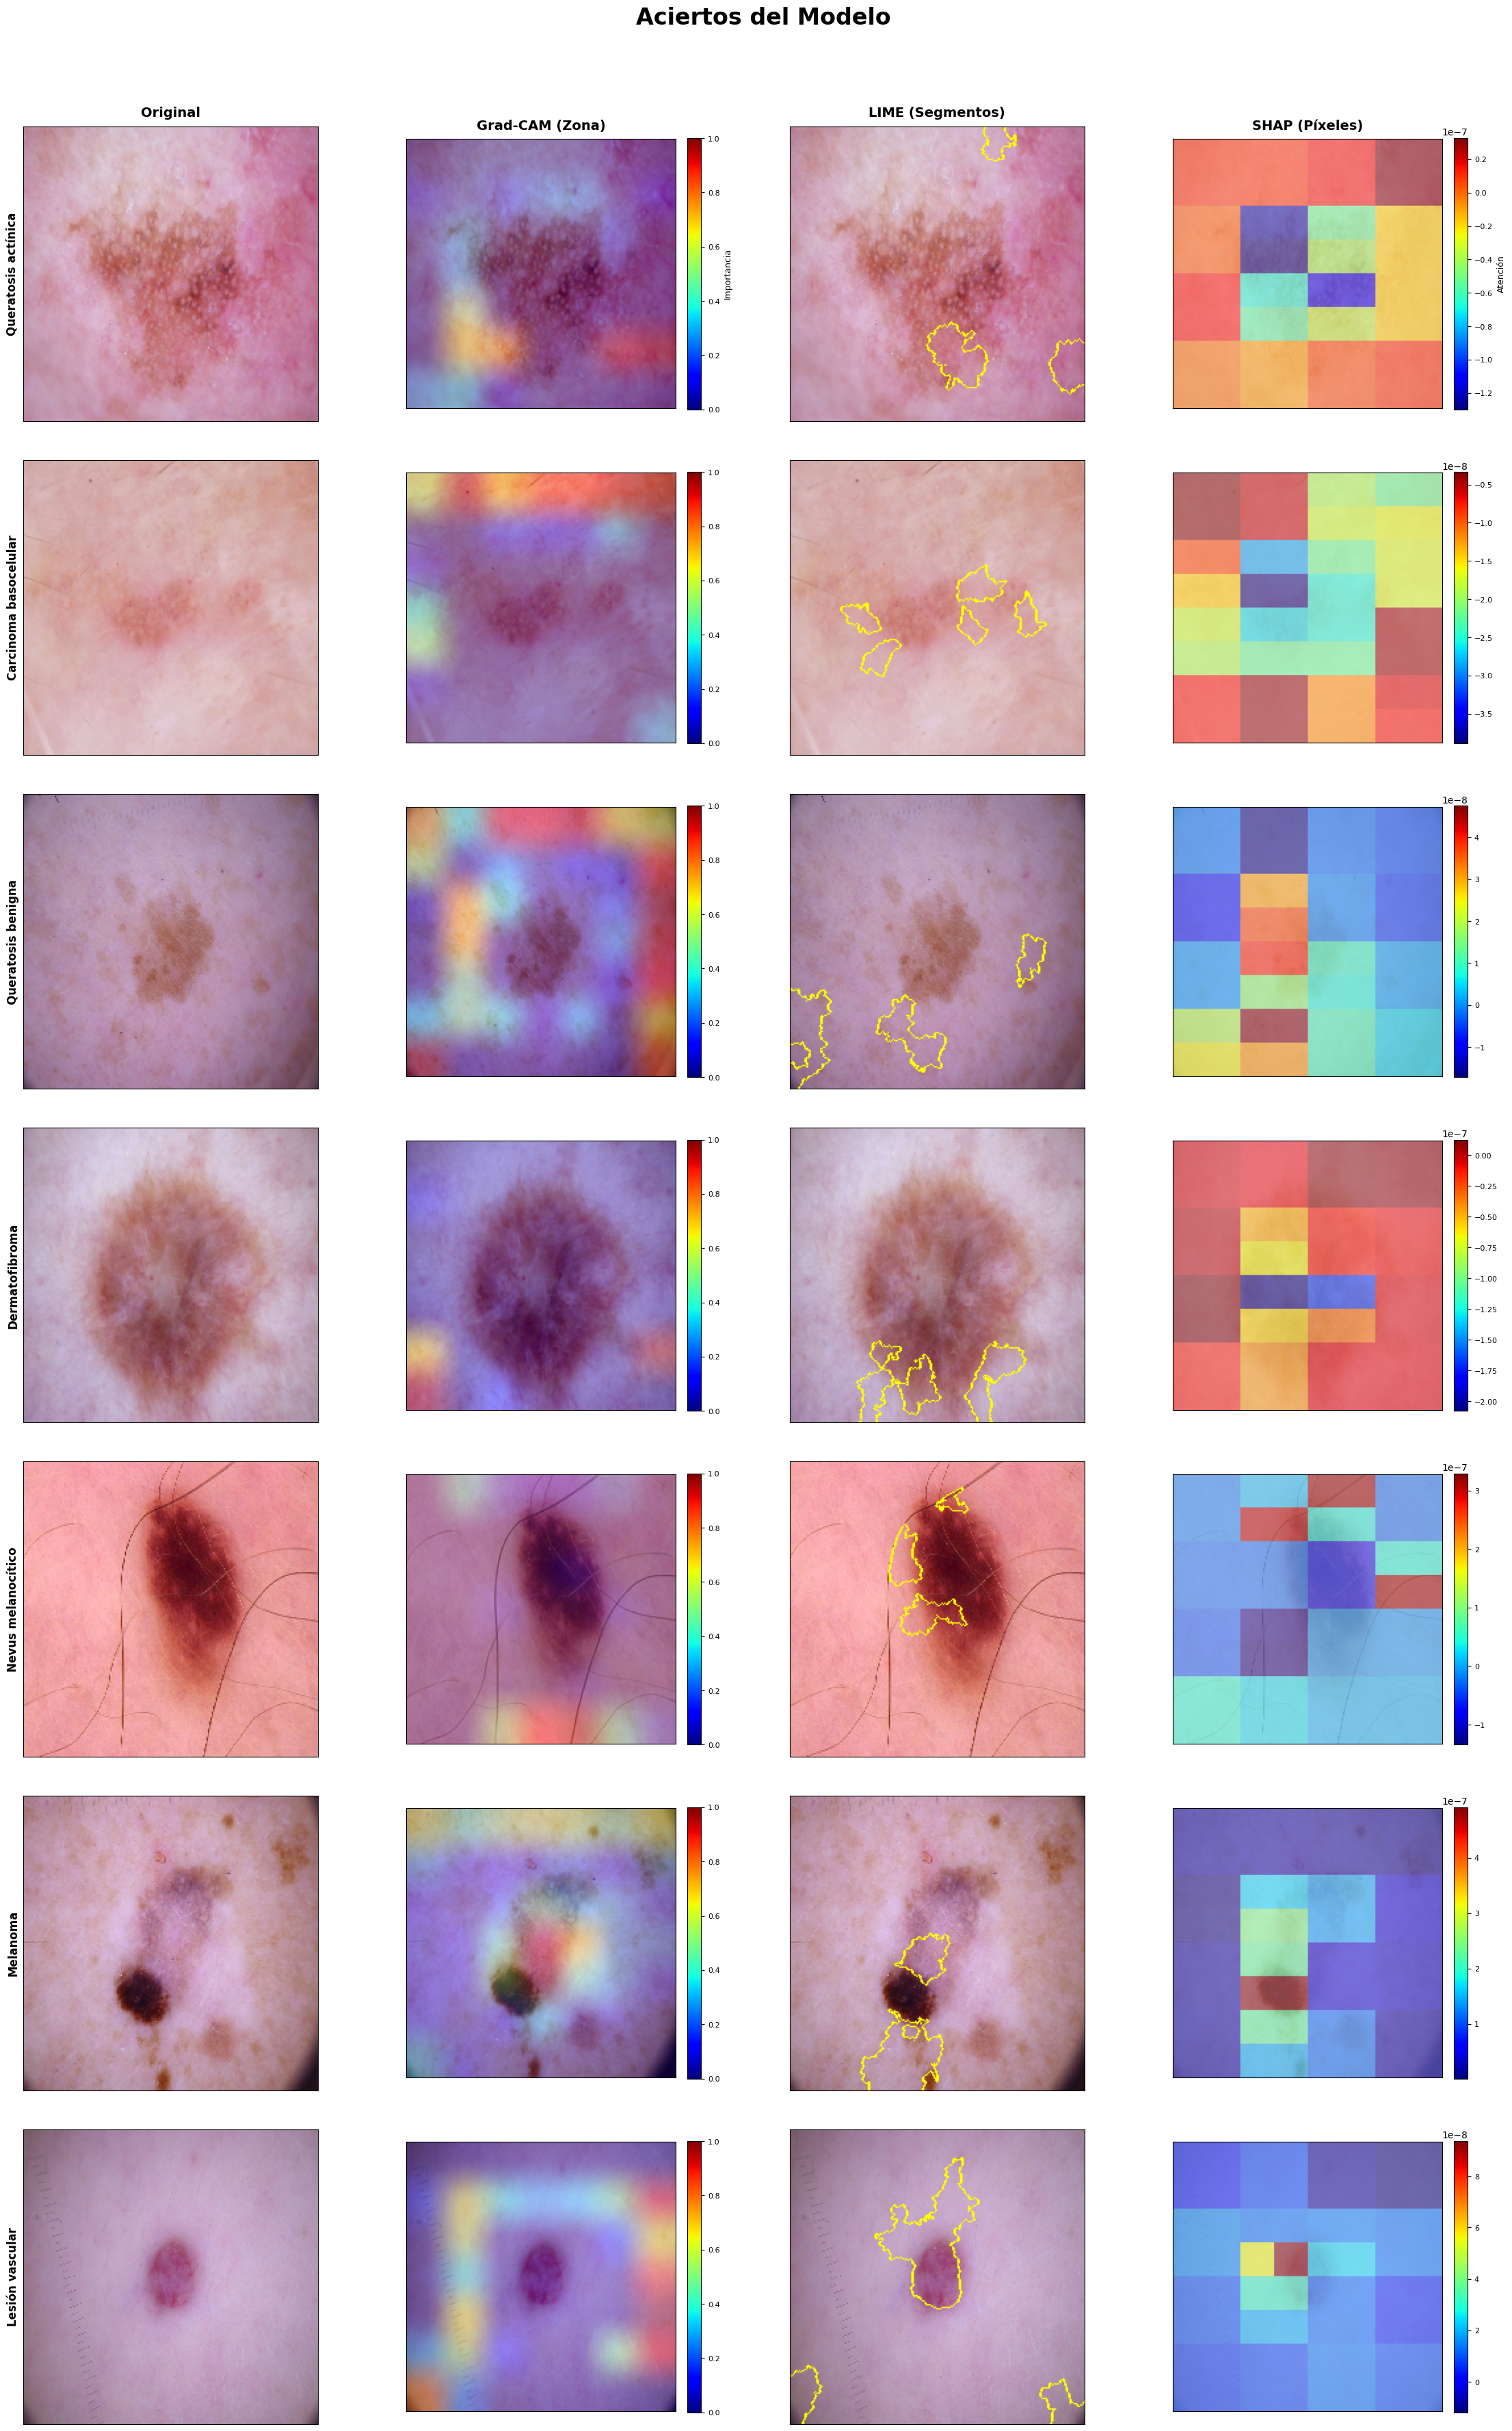

In [21]:


# ==========================================
# 1. FUNCIONES CORE XAI
# ==========================================

def get_gradcam_heatmap(img_input, meta_input, model, last_conv_layer_name, pred_index):
    v_model = model.get_layer('resnet50')
    inner_model = tf.keras.Model(
        inputs=v_model.inputs, 
        outputs=[v_model.get_layer(last_conv_layer_name).output, v_model.output]
    )
    pool_layer = [l for l in model.layers if isinstance(l, tf.keras.layers.GlobalAveragePooling2D)][0]
    concat_layer = [l for l in model.layers if isinstance(l, tf.keras.layers.Concatenate)][0]
    meta_branch = tf.keras.Model(inputs=model.input[1], outputs=concat_layer.input[1])
    
    top_input = tf.keras.Input(shape=concat_layer.output.shape[1:])
    x = top_input
    idx = model.layers.index(concat_layer)
    for layer in model.layers[idx+1:]:
        x = layer(x)
    top_model = tf.keras.Model(inputs=top_input, outputs=x)

    with tf.GradientTape() as tape:
        conv_output, backbone_out = inner_model(img_input)
        x_img = pool_layer(backbone_out)
        x_meta = meta_branch(meta_input)
        combined_features = concat_layer([x_img, x_meta])
        predictions = top_model(combined_features)
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_output[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

def superimpose_heatmap(img_path, heatmap, alpha=0.4):
    img = tf.keras.utils.load_img(img_path)
    img_arr = tf.keras.utils.img_to_array(img)
    heatmap_arr = np.uint8(255 * heatmap)
    jet = plt.get_cmap("jet")(np.arange(256))[:, :3]
    jet_heatmap = tf.keras.utils.array_to_img(jet[heatmap_arr]).resize((img_arr.shape[1], img_arr.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)
    return tf.keras.utils.array_to_img(jet_heatmap * alpha + img_arr)

# ==========================================
# 2. FUNCIÓN DE BÚSQUEDA INTELIGENTE
# ==========================================

def buscar_ejemplo(class_idx, test_df, mode='correct'):
    """ Busca en el set de test una imagen que el modelo haya acertado o fallado """
    df_filtrado = test_df[test_df['label'] == class_idx].sample(frac=1, random_state=42) # Aleatorizar
    
    for _, row in df_filtrado.iterrows():
        img_path = row['path']
        current_meta = np.array([row['meta']], dtype=np.float32)
        
        # Preparar imagen
        img_raw = tf.keras.utils.load_img(img_path, target_size=(224, 224))
        img_array = tf.keras.utils.img_to_array(img_raw)
        img_input = np.expand_dims(img_array, axis=0) / 255.0
        
        # Predecir
        pred = final_model.predict([img_input, current_meta], verbose=0)
        pred_idx = np.argmax(pred[0])
        
        # Comprobar condición
        if mode == 'correct' and pred_idx == class_idx:
            return img_path, img_input, img_raw, current_meta, pred_idx
        elif mode == 'incorrect' and pred_idx != class_idx:
            return img_path, img_input, img_raw, current_meta, pred_idx
            
    return None # Si no encuentra ninguna (ej. si ha acertado el 100% no hay incorrectas)

# ==========================================
# 3. GENERACIÓN DE TABLAS
# ==========================================

sub_model = final_model.get_layer('resnet50')
last_conv_name = [l.name for l in sub_model.layers if 'conv' in l.name.lower()][-1]
explainer_lime = lime_image.LimeImageExplainer()
col_titles = ['Original', 'Grad-CAM (Zona)', 'LIME (Segmentos)', 'SHAP (Píxeles)']

#modos = ['correct', 'incorrect']
modos = ['correct']
titulos_tabla = ["Aciertos del Modelo", "Fallos del Modelo (Errores de Predicción)"]

for mode, titulo in zip(modos, titulos_tabla):
    print(f"\n🚀 Generando tabla de: {titulo}...")
    
    n_clases = len(class_names)
    fig, axes = plt.subplots(nrows=n_clases, ncols=4, figsize=(22, 5 * n_clases))
    fig.suptitle(titulo, fontsize=24, fontweight='bold', y=1.02)
    
    # Silenciamos la verbosidad de SHAP y LIME
    with open(os.devnull, 'w') as f, contextlib.redirect_stdout(f), contextlib.redirect_stderr(f):
        for i, nombre_clase in enumerate(class_names):
            
            # Buscar la imagen adecuada
            resultado = buscar_ejemplo(i, test_df, mode=mode)
            
            if resultado is None:
                # Si no hay errores para esta clase, mostramos un mensaje vacío
                axes[i, 0].text(0.5, 0.5, "Sin ejemplos disponibles", ha='center', va='center')
                axes[i, 0].set_ylabel(class_names_es[i], fontsize=12, fontweight='bold')
                for j in range(1, 4): axes[i, j].axis('off')
                continue
                
            img_path, img_input, img_raw, current_meta, pred_idx = resultado

            # C. WRAPPER PARA LIME/SHAP
            def hybrid_predict(batch):
                m_batch = np.repeat(current_meta, batch.shape[0], axis=0)
                return final_model.predict([batch, m_batch], verbose=0)

            # 1. Grad-CAM
            h_map = get_gradcam_heatmap(img_input, current_meta, final_model, last_conv_name, pred_idx)
            gcam_res = superimpose_heatmap(img_path, h_map).resize((224, 224))
            mappable1 = cm.ScalarMappable(cmap="jet")
            mappable1.set_array([np.min(h_map), np.max(h_map)])
            cbar1 = plt.colorbar(mappable1, ax=axes[i, 1], fraction=0.046, pad=0.04)
            cbar1.ax.tick_params(labelsize=8)
            if i == 0: cbar1.set_label('Importancia', fontsize=9)
            
            # 2. LIME
            exp = explainer_lime.explain_instance(
                img_input[0].astype('double'), 
                hybrid_predict, 
                top_labels=1, 
                num_samples=500,
                segmentation_fn=lambda x: quickshift(x, kernel_size=3, max_dist=6, ratio=0.5)
                #segmentation_fn=lambda x: slic(x, n_segments=250, compactness=10, sigma=1, start_label=1)
                #segmentation_fn=lambda x: felzenszwalb(x, scale=100, sigma=0.5, min_size=50)
                #segmentation_fn=lambda x: watershed(sobel(rgb2gray(x)), markers=250, compactness=0.001)
            )
            temp, mask = exp.get_image_and_mask(exp.top_labels[0], positive_only=True, num_features=5, hide_rest=False)
            
            # 3. SHAP
            masker = shap.maskers.Image("blur(16,16)", shape=(224, 224, 3))
            expl_shap = shap.Explainer(hybrid_predict, masker, output_names=class_names_es)
            sv = expl_shap(img_input, max_evals=200, batch_size=50)
            #abs_s = np.abs(sv.values[0, :, :, :, pred_idx]).sum(axis=-1)
            shap_map = sv.values[0, :, :, :, pred_idx].sum(axis=-1)
            #vmax = np.max(np.abs(shap_map))
            mappable3 = cm.ScalarMappable(cmap="jet")
            mappable3.set_array([np.min(shap_map), np.max(shap_map)])
            cbar3 = plt.colorbar(mappable3, ax=axes[i, 3], fraction=0.046, pad=0.04)
            cbar3.ax.tick_params(labelsize=8)
            if i == 0: cbar3.set_label('Atención', fontsize=9)

            # --- RENDERIZADO ---
            axes[i, 0].imshow(img_raw)
            
            # Si es modo incorrecto, mostramos qué predijo realmente
            if mode == 'correct':
                etiqueta = class_names_es[i]
            else:
                etiqueta = f"Real: {class_names_es[i]}\nPredijo: {class_names_es[pred_idx]}"
                
            axes[i, 0].set_ylabel(etiqueta, fontsize=12, fontweight='bold', color='red' if mode=='incorrect' else 'black')
            
            axes[i, 1].imshow(gcam_res)
            axes[i, 2].imshow(mark_boundaries(temp, mask))
            #axes[i, 3].imshow(img_raw, alpha=0.3)
            #axes[i, 3].imshow(shap_map, cmap='hot', alpha=0.5)
            axes[i, 3].imshow(img_raw, alpha=0.5)
            axes[i, 3].imshow(
                shap_map,
                cmap='jet',   # o 'bwr', 'coolwarm'
                alpha=0.5,
                vmin=np.min(shap_map),
                vmax=np.max(shap_map)
            )

            # Limpiar ejes y poner títulos solo en la primera fila
            for j in range(4):
                axes[i, j].set_xticks([]); axes[i, j].set_yticks([])
                if i == 0: axes[i, j].set_title(col_titles[j], fontweight='bold', fontsize=14, pad=10)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3)
    plt.show()

In [ ]:
## ==========================================
## COMPARATIVA DE LIME CON DIFERENTES PARÁMETROS DE QUICKSHIFT
## ==========================================
#
#def hybrid_predict(batch, img_input, current_meta, final_model):
#    """Wrapper para que LIME pueda hacer predicciones con el modelo híbrido"""
#    m_batch = np.repeat(current_meta, batch.shape[0], axis=0)
#    return final_model.predict([batch, m_batch], verbose=0)
#
## 1. SELECCIONAR UNA IMAGEN DE EJEMPLO (ACIERTO DEL MODELO)
#def buscar_ejemplo_correcta(test_df, final_model):
#    """Busca una imagen donde el modelo haya acertado"""
#    for idx, row in test_df.iterrows():
#        img_path = row['path']
#        current_meta = np.array([row['meta']], dtype=np.float32)
#        label_real = row['label']
#        
#        # Preparar imagen
#        img_raw = tf.keras.utils.load_img(img_path, target_size=(224, 224))
#        img_array = tf.keras.utils.img_to_array(img_raw)
#        img_input = np.expand_dims(img_array, axis=0) / 255.0
#        
#        # Predecir
#        pred = final_model.predict([img_input, current_meta], verbose=0)
#        pred_idx = np.argmax(pred[0])
#        
#        # Si acierta, devolvemos
#        if pred_idx == label_real:
#            return img_path, img_input, img_raw, current_meta, label_real, pred_idx
#    
#    return None
#
#print("🔍 Buscando una imagen de ejemplo para la comparativa LIME...")
#resultado = buscar_ejemplo_correcta(test_df, final_model)
#
#if resultado is None:
#    print("❌ No se encontró ninguna imagen con acierto. Usando la primera del test set.")
#    row = test_df.iloc[0]
#    img_path = row['path']
#    current_meta = np.array([row['meta']], dtype=np.float32)
#    img_raw = tf.keras.utils.load_img(img_path, target_size=(224, 224))
#    img_array = tf.keras.utils.img_to_array(img_raw)
#    img_input = np.expand_dims(img_array, axis=0) / 255.0
#    label_real = row['label']
#    pred = final_model.predict([img_input, current_meta], verbose=0)
#    pred_idx = np.argmax(pred[0])
#else:
#    img_path, img_input, img_raw, current_meta, label_real, pred_idx = resultado
#
#print(f"✅ Imagen seleccionada: {class_names_es[label_real]}")
#print(f"   Ruta: {img_path}")
#
## 2. DEFINIR RANGOS DE PARÁMETROS (SALTANDO UN NÚMERO)
#kernel_sizes = list(range(1, 11, 2))      # [1, 3, 5, 7, 9]
#max_dists = list(range(1, 11, 2))         # [1, 3, 5, 7, 9]
#ratios = np.arange(0.1, 1.0, 0.2)         # [0.1, 0.3, 0.5, 0.7, 0.9]
#
#print(f"\n📊 Parámetros a probar:")
#print(f"   - kernel_size: {kernel_sizes}")
#print(f"   - max_dist: {max_dists}")
#print(f"   - ratio: {list(ratios)}")
#print(f"   - Total de combinaciones: {len(kernel_sizes) * len(max_dists) * len(ratios)}")
#
## 3. CREAR EXPLAINER LIME
#explainer_lime = lime_image.LimeImageExplainer()
#
## 4. EJECUTAR LIME PARA TODAS LAS COMBINACIONES
#print("\n🚀 Generando explicaciones LIME para todas las combinaciones...")
#
#resultados_lime = []
#
#with open(os.devnull, 'w') as f, contextlib.redirect_stdout(f), contextlib.redirect_stderr(f):
#    combinacion = 0
#    total_combinaciones = len(kernel_sizes) * len(max_dists) * len(ratios)
#    
#    for kernel_size in kernel_sizes:
#        for max_dist in max_dists:
#            for ratio in ratios:
#                combinacion += 1
#                
#                # Mostrar progreso cada 10 combinaciones
#                if combinacion % 10 == 0 or combinacion == 1:
#                    print(f"   [{combinacion}/{total_combinaciones}] Procesando: kernel_size={kernel_size}, max_dist={max_dist}, ratio={ratio:.1f}")
#                
#                # Ejecutar LIME con estos parámetros
#                exp = explainer_lime.explain_instance(
#                    img_input[0].astype('double'),
#                    lambda batch: hybrid_predict(batch, img_input, current_meta, final_model),
#                    top_labels=1,
#                    num_samples=500,
#                    segmentation_fn=lambda x: quickshift(x, kernel_size=kernel_size, max_dist=max_dist, ratio=ratio)
#                )
#                
#                # Extraer máscara y imagen superpuesta
#                temp, mask = exp.get_image_and_mask(
#                    exp.top_labels[0], 
#                    positive_only=True, 
#                    num_features=5, 
#                    hide_rest=False
#                )
#                
#                # Guardar resultado
#                resultados_lime.append({
#                    'kernel_size': kernel_size,
#                    'max_dist': max_dist,
#                    'ratio': ratio,
#                    'imagen_segmentada': mark_boundaries(temp, mask),
#                    'imagen_original': img_raw
#                })
#
#print(f"✅ Se generaron {len(resultados_lime)} explicaciones LIME.")
#
## 5. VISUALIZAR LOS RESULTADOS EN GRILLAS
#print(f"\n📈 Visualizando resultados en grillas...")
#
## Definir cómo organizar las imágenes (por ejemplo, 10 columnas)
#cols_per_grid = 10
#rows_per_grid = 10  # 10x10 = 100 imágenes por figura
#
## Calcular cuántas figuras necesitamos
#num_grids = (len(resultados_lime) + rows_per_grid * cols_per_grid - 1) // (rows_per_grid * cols_per_grid)
#
## Crear cada grilla
#for grid_idx in range(num_grids):
#    start_idx = grid_idx * rows_per_grid * cols_per_grid
#    end_idx = min(start_idx + rows_per_grid * cols_per_grid, len(resultados_lime))
#    
#    subset = resultados_lime[start_idx:end_idx]
#    
#    # Calcular dimensiones de la grilla
#    n_images = len(subset)
#    n_cols = min(cols_per_grid, n_images)
#    n_rows = (n_images + n_cols - 1) // n_cols
#    
#    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(25, 25))
#    
#    # Si es una sola fila o columna, axes no es 2D
#    if n_rows == 1 or n_cols == 1:
#        axes = axes.reshape(n_rows, n_cols)
#    
#    fig.suptitle(
#        f"Comparativa LIME - {class_names_es[label_real]}\nGridilla {grid_idx + 1}/{num_grids}",
#        fontsize=20,
#        fontweight='bold',
#        y=0.995
#    )
#    
#    for img_idx, (ax, resultado) in enumerate(zip(axes.flat, subset)):
#        # Mostrar imagen segmentada
#        ax.imshow(resultado['imagen_segmentada'])
#        
#        # Crear título con parámetros
#        titulo = (f"k={resultado['kernel_size']}, "
#                 f"d={resultado['max_dist']}, "
#                 f"r={resultado['ratio']:.1f}")
#        
#        ax.set_title(titulo, fontsize=11, fontweight='bold', pad=8)
#        ax.axis('off')
#    
#    # Desactivar ejes sobrantes
#    for ax in axes.flat[len(subset):]:
#        ax.axis('off')
#    
#    plt.tight_layout()
#    plt.show()
#
#print("\n✅ ¡Comparativa de LIME completada!")
#print(f"💡 Tip: Observa las diferencias en la segmentación según los parámetros de quickshift.")
#